In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scripts.database import engine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      3.0.2
   numpy       2.4.4
   seaborn     0.13.2
   statsmodels 0.14.6


In [2]:
# ── CELDA 2: Carga de datos ───────────────────────────────────
QUERY = """
SELECT
    lc.launch_id,
    lc.flight_number,
    lc.rocket_name,
    lc.success,
    lc.payload_count,
    lc.total_payload_mass,
    lc.core_count,
    lc.reused_cores,
    l.date_utc,
    l.name AS launch_name,
    r.cost_per_launch,
    r.success_rate_pct,
    r.mass_kg AS rocket_mass,
    r.thrust_to_weight,
    r.height_m,
    r.diameter_m
FROM launches_central lc
JOIN launches l ON lc.launch_id = l.launch_id
JOIN rockets r ON l.rocket_id = r.rocket_id
ORDER BY l.date_utc;
"""
df = pd.read_sql(QUERY, engine)
print(f"✅ Datos cargados exitosamente desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Primeras filas:")
df.head()


2026-04-15 15:00:54,606 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2026-04-15 15:00:54,608 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-04-15 15:00:54,613 INFO sqlalchemy.engine.Engine select current_schema()
2026-04-15 15:00:54,614 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-04-15 15:00:54,618 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2026-04-15 15:00:54,620 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-04-15 15:00:54,772 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-04-15 15:00:54,775 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname

,launch_id,flight_number,rocket_name,success,payload_count,total_payload_mass,core_count,reused_cores,date_utc,launch_name,cost_per_launch,success_rate_pct,rocket_mass,thrust_to_weight,height_m,diameter_m
0,launch_499,499,Falcon 1,True,1,7990.0,1,1,2024-12-02 19:59:49.559640,Mission 499,7000000,40,30000,90.0,22.0,1.7
1,launch_498,498,Falcon 9,True,1,15819.0,1,1,2024-12-03 19:59:49.559622,Mission 498,50000000,98,550000,180.0,70.0,3.7
2,launch_497,497,Falcon 9,True,1,15147.0,1,1,2024-12-04 19:59:49.559603,Mission 497,50000000,98,550000,180.0,70.0,3.7
3,launch_496,496,Falcon Heavy,True,1,17867.0,1,0,2024-12-05 19:59:49.559581,Mission 496,90000000,95,1400000,220.0,70.0,3.7
4,launch_495,495,Falcon Heavy,True,1,18942.0,1,1,2024-12-06 19:59:49.559562,Mission 495,90000000,95,1400000,220.0,70.0,3.7


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(df.info())
print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n🚀 Distribución por tipo de cohete:")
print(df['rocket_name'].value_counts())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   launch_id           500 non-null    str           
 1   flight_number       500 non-null    int64         
 2   rocket_name         500 non-null    str           
 3   success             500 non-null    bool          
 4   payload_count       500 non-null    int64         
 5   total_payload_mass  500 non-null    float64       
 6   core_count          500 non-null    int64         
 7   reused_cores        500 non-null    int64         
 8   date_utc            500 non-null    datetime64[us]
 9   launch_name         500 non-null    str           
 10  cost_per_launch     500 non-null    int64         
 11  success_rate_pct    500 non-null    int64         
 12  rocket_mass         500 non-null    int64         
 13  thrust_to_weight    500 non

In [4]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
# ⚠️ Se excluyen payload_count y core_count: std=0, son constantes
# y no aportan información para modelado.
vars_num = [
    'total_payload_mass',
    'reused_cores',
    'cost_per_launch',
    'success_rate_pct',
    'rocket_mass',
    'thrust_to_weight',
    'height_m',
    'diameter_m'
]
desc = df[vars_num].describe().round(2)
print("📊 ESTADÍSTICAS DESCRIPTIVAS (variables con variabilidad real)")
print(desc)


📊 ESTADÍSTICAS DESCRIPTIVAS (variables con variabilidad real)
       total_payload_mass  reused_cores  cost_per_launch  success_rate_pct  \
count              500.00        500.00            500.0            500.00   
mean             13733.36          0.57       48524000.0             77.78   
std               4428.75          0.49       33555048.9             26.69   
min               6694.00          0.00        7000000.0             40.00   
25%               8366.50          0.00        7000000.0             40.00   
50%              15172.00          1.00       50000000.0             95.00   
75%              17671.75          1.00       90000000.0             98.00   
max              19642.00          1.00       90000000.0             98.00   

       rocket_mass  thrust_to_weight  height_m  diameter_m  
count       500.00            500.00    500.00      500.00  
mean     649360.00            162.92     54.06        3.04  
std      558322.34             53.99     22.63      

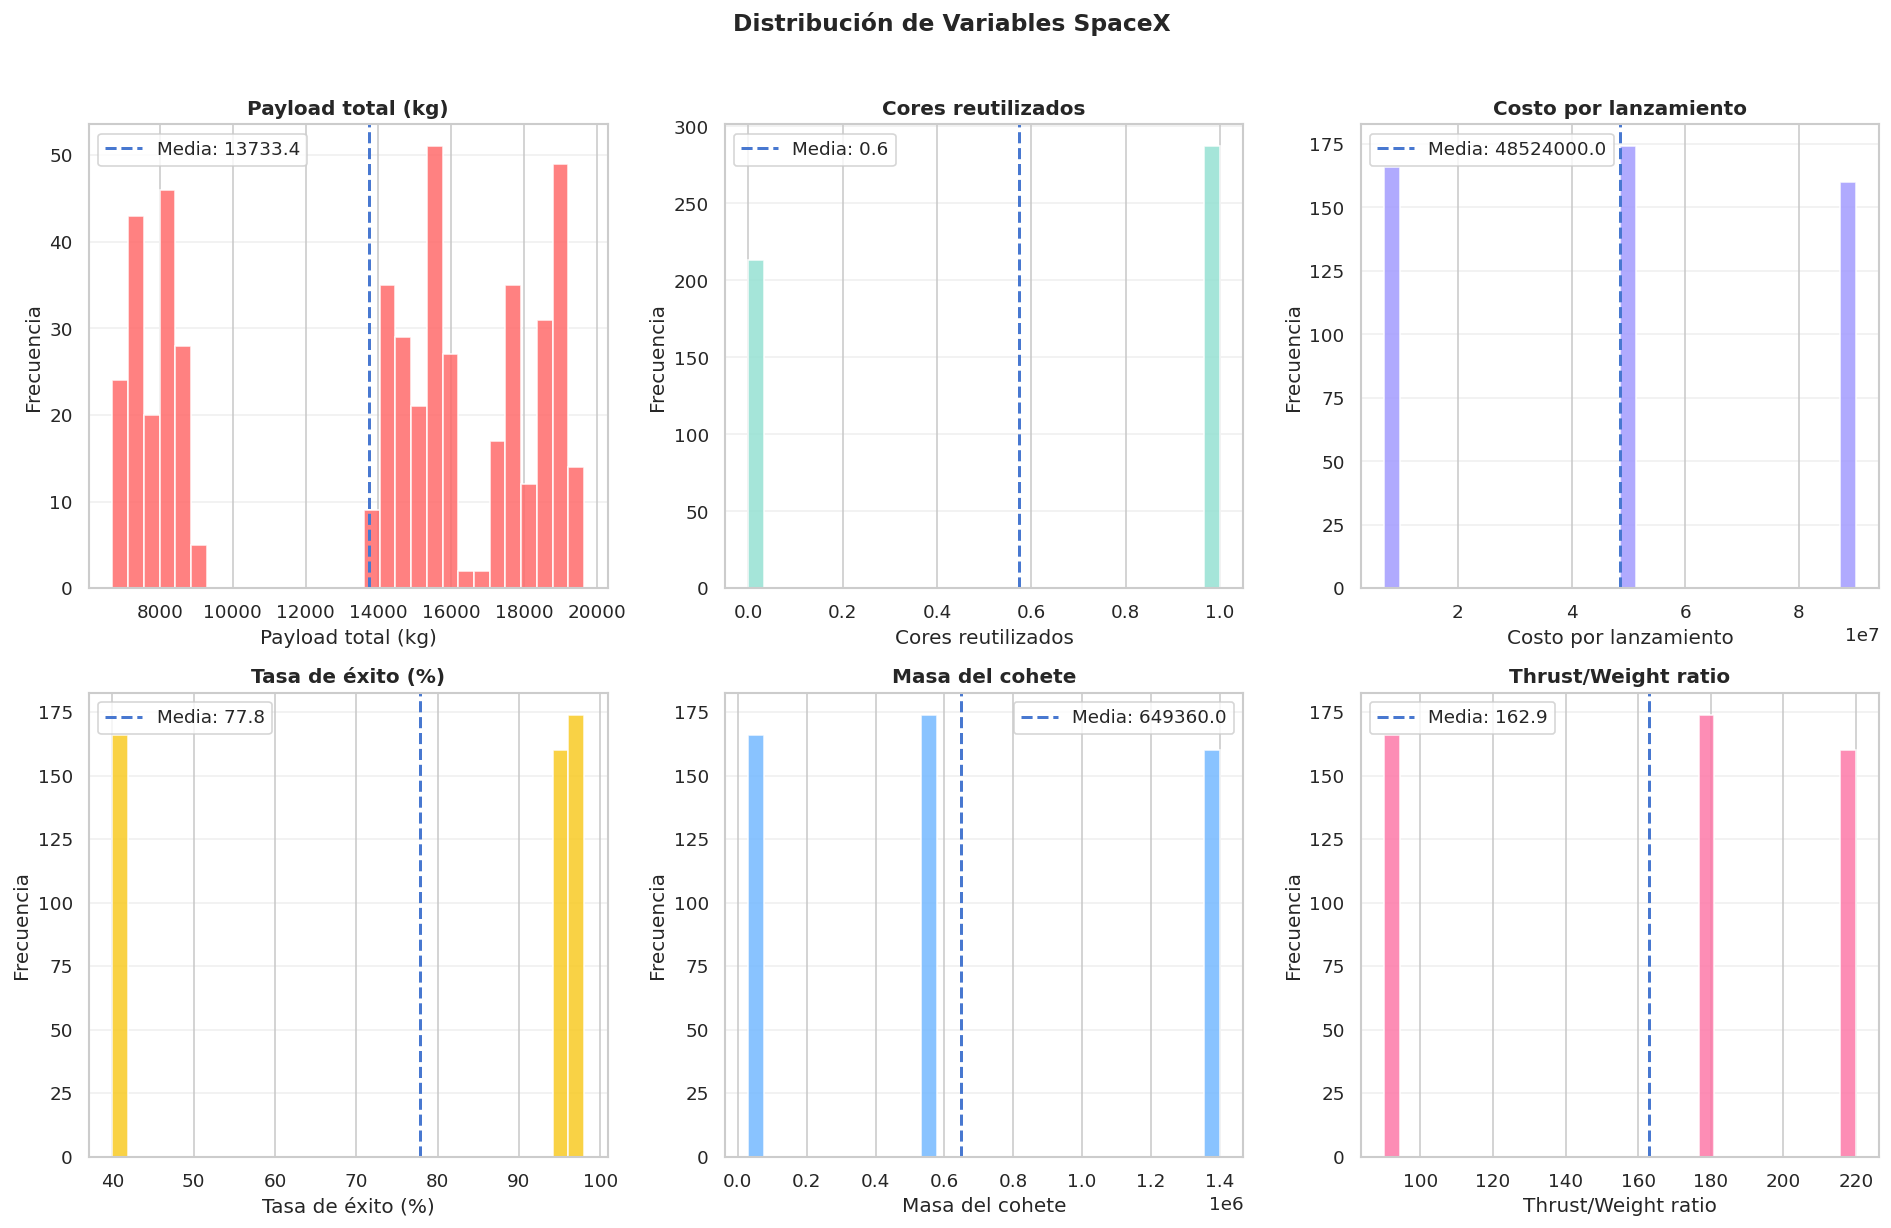

In [5]:
# ── CELDA 5: Histogramas de distribución ─────────────────────
# Se reemplazan payload_count y core_count por variables informativas
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables SpaceX',
             fontsize=14, fontweight='bold', y=1.02)

datos = {
    'total_payload_mass': ('Payload total (kg)',      '#ff6b6b'),
    'reused_cores':       ('Cores reutilizados',      '#95e1d3'),
    'cost_per_launch':    ('Costo por lanzamiento',   '#a29bfe'),
    'success_rate_pct':   ('Tasa de éxito (%)',        '#f9ca24'),
    'rocket_mass':        ('Masa del cohete',          '#74b9ff'),
    'thrust_to_weight':   ('Thrust/Weight ratio',      '#fd79a8'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, linestyle='--', linewidth=1.8,
               label=f'Media: {media:.1f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_24550/1321260556.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='rocket_name', y='total_payload_mass',
/tmp/ipykernel_24550/1321260556.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='rocket_name', y='cost_per_launch',


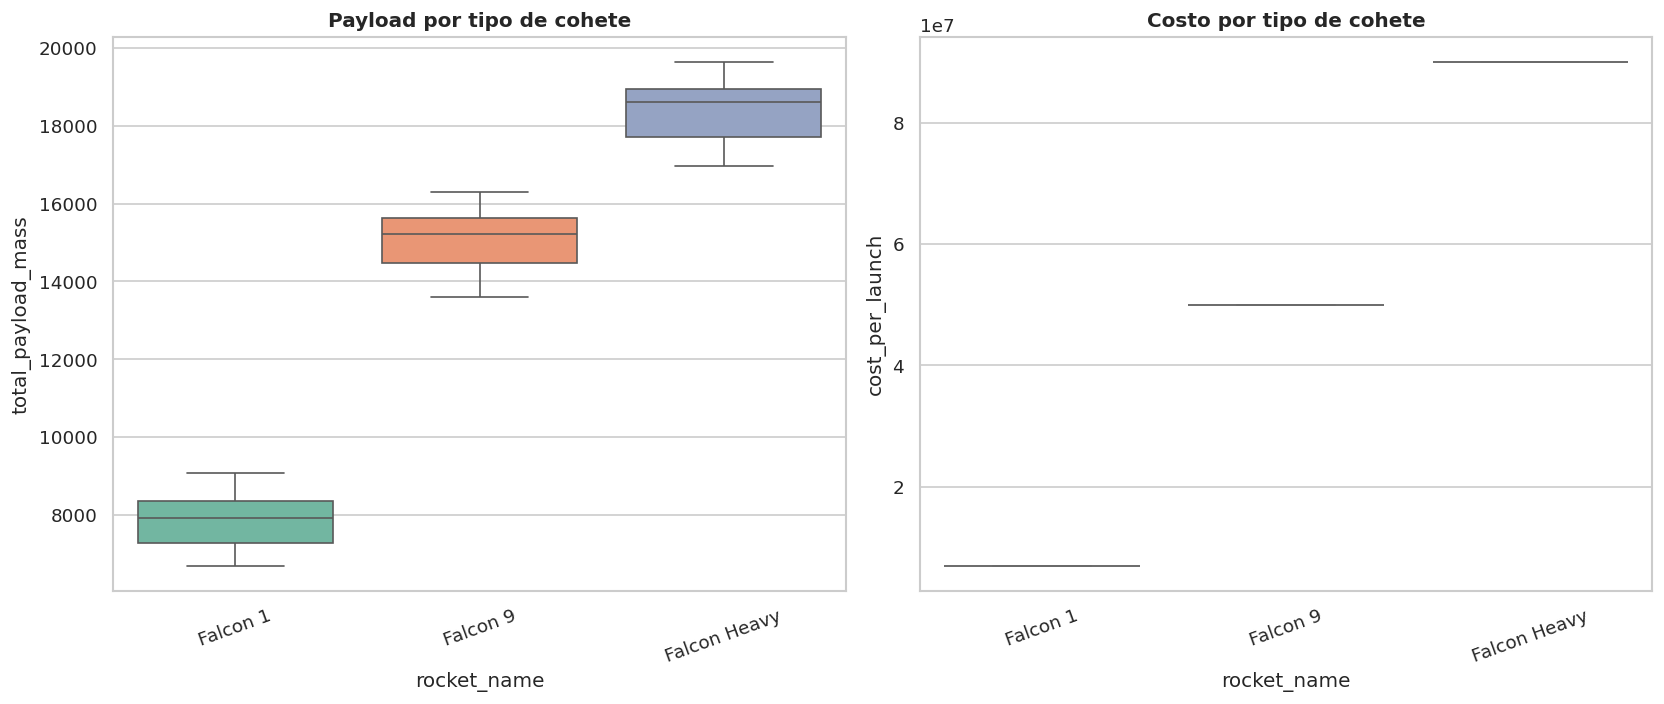

In [6]:
# ── CELDA 6: Boxplots por tipo de cohete ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
orden = df.groupby('rocket_name')['total_payload_mass'] \
           .median().sort_values().index

sns.boxplot(data=df, x='rocket_name', y='total_payload_mass',
            order=orden, palette='Set2', ax=axes[0])
axes[0].set_title('Payload por tipo de cohete', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='rocket_name', y='cost_per_launch',
            order=orden, palette='Set3', ax=axes[1])
axes[1].set_title('Costo por tipo de cohete', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

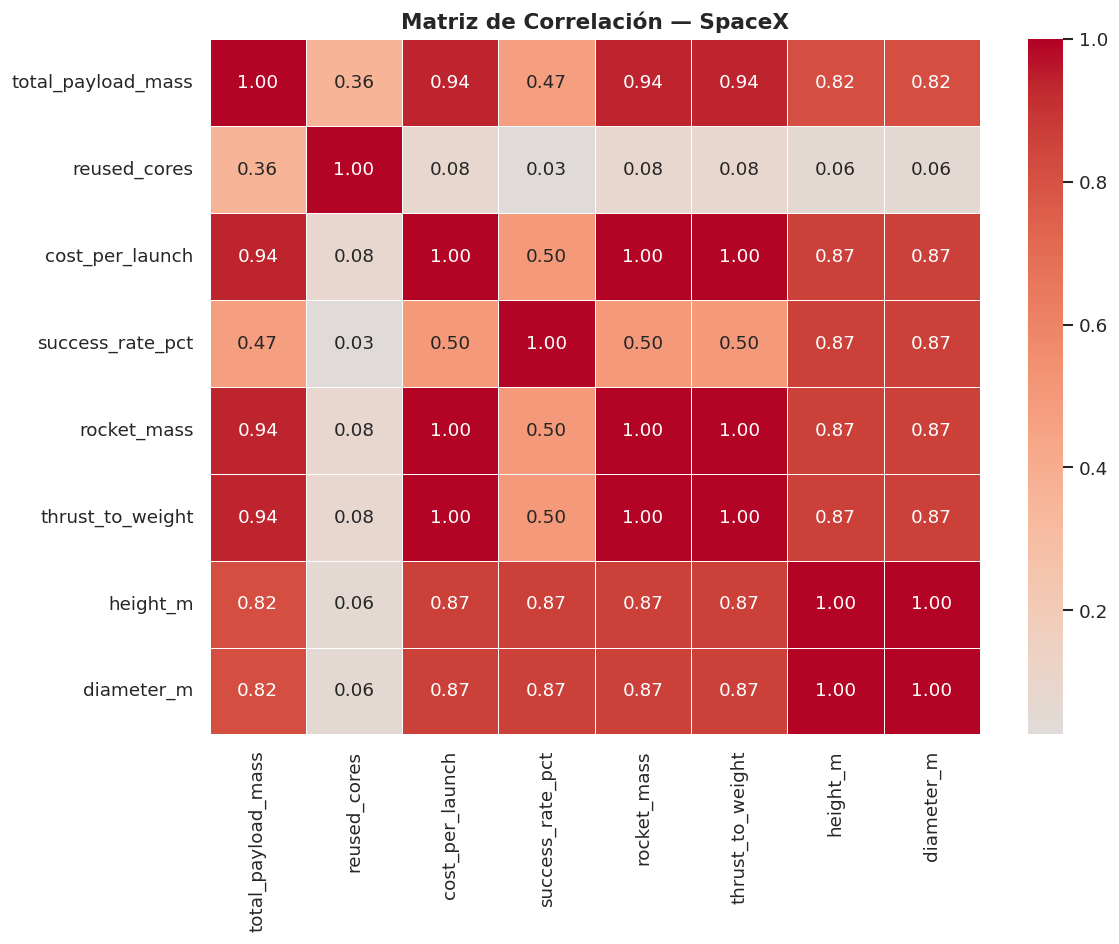


📊 Correlación con total_payload_mass:
total_payload_mass    1.000
cost_per_launch       0.943
thrust_to_weight      0.943
rocket_mass           0.943
height_m              0.816
diameter_m            0.816
success_rate_pct      0.469
reused_cores          0.360
Name: total_payload_mass, dtype: float64

📊 VIF por variable (>5 indica multicolinealidad problemática):
        Variable  VIF
 cost_per_launch  inf
success_rate_pct  inf
     rocket_mass  inf
        height_m  inf
thrust_to_weight  inf
      diameter_m  inf
    reused_cores 1.01


/home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/04-jupyter-impl/venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [7]:
# ── CELDA 7: Matriz de correlación + VIF ─────────────────────
corr = df[vars_num].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Matriz de Correlación — SpaceX',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Correlación con total_payload_mass:")
print(corr['total_payload_mass'].sort_values(ascending=False).round(3))

# VIF para detectar multicolinealidad entre predictores
print("\n📊 VIF por variable (>5 indica multicolinealidad problemática):")
predictores_vif = [v for v in vars_num if v != 'total_payload_mass']
X_vif = df[predictores_vif].copy()
vif_data = pd.DataFrame({
    'Variable': predictores_vif,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).round(2)
print(vif_data.to_string(index=False))

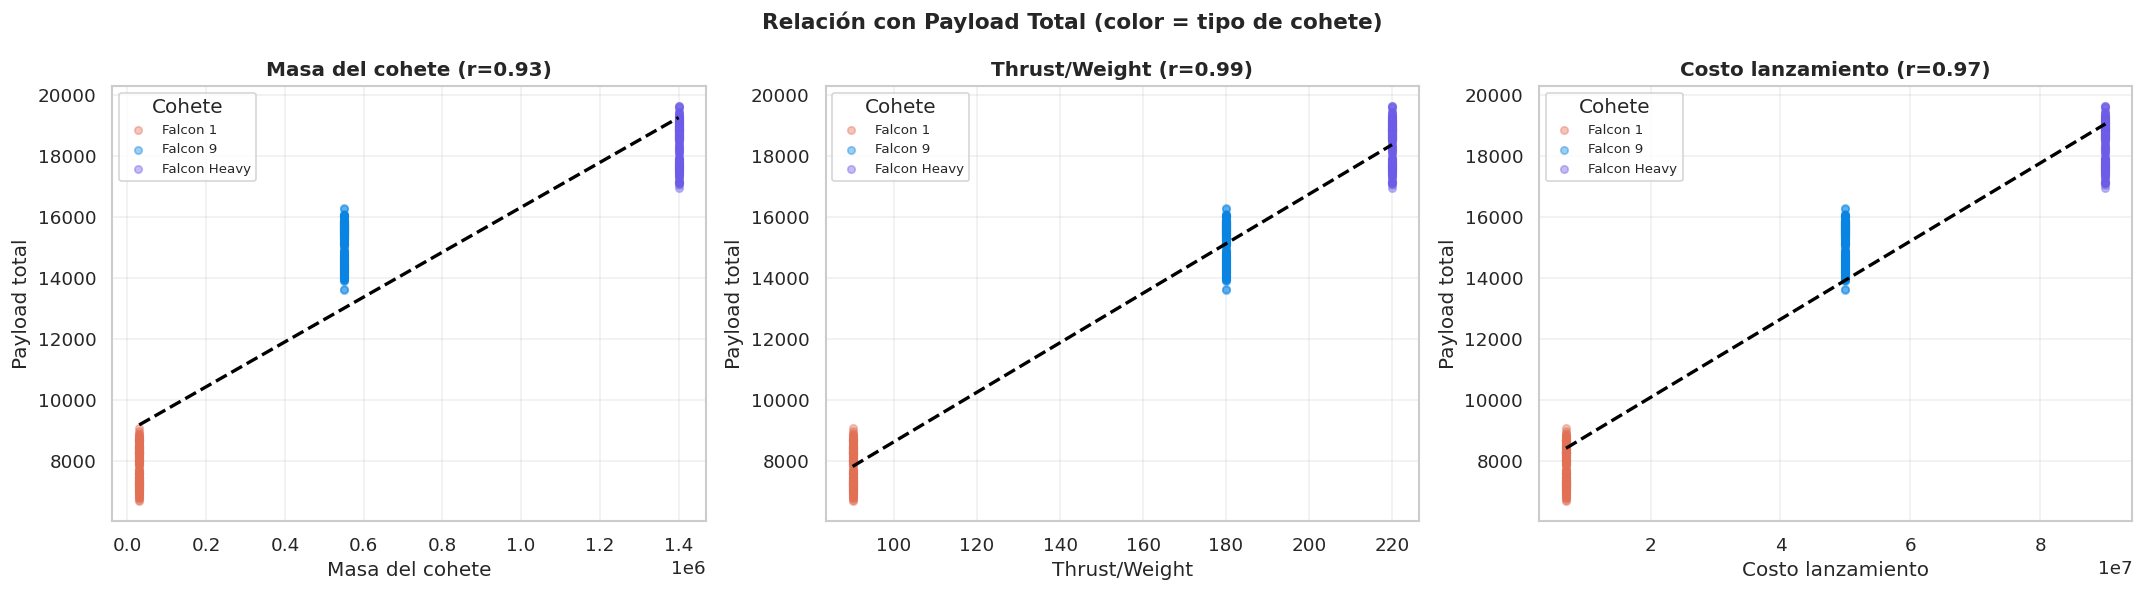

In [17]:
# ── CELDA 8: Scatter plots vs total_payload_mass ─────────────
# Se añade color por rocket_name para evidenciar las 3 poblaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación con Payload Total (color = tipo de cohete)',
             fontsize=13, fontweight='bold')

pares = [
    ('rocket_mass',      'Masa del cohete'),
    ('thrust_to_weight', 'Thrust/Weight'),
    ('cost_per_launch',  'Costo lanzamiento'),
]
palette = {'Falcon 1': '#e17055', 'Falcon 9': '#0984e3',
           'Falcon Heavy': '#6c5ce7'}

for ax, (feature, label) in zip(axes, pares):
    for rocket, grp in df.groupby('rocket_name'):
        ax.scatter(grp[feature], grp['total_payload_mass'],
                   alpha=0.4, s=20, label=rocket,
                   color=palette.get(rocket, 'gray'))
    # línea de tendencia global
    z = np.polyfit(df[feature], df['total_payload_mass'], 1)
    p = np.poly1d(z)
    xp = np.linspace(df[feature].min(), df[feature].max(), 100)
    ax.plot(xp, p(xp), color='black', linewidth=2, linestyle='--')
    r = df[[feature, 'total_payload_mass']].corr().iloc[0, 1]
    ax.set_title(f'{label} (r={r:.2f})', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Payload total')
    ax.legend(title='Cohete', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# ── CELDA 9: Split Train / Test ───────────────────────────────
X_simple = df[['thrust_to_weight']].values
y        = df['total_payload_mass'].values
 
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)
 
print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 400 muestras (80%)
Test : 100 muestras  (20%)


In [10]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)
 
y_pred_simple = modelo_simple.predict(X_test)
 
print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")
print(f"\nEcuación : total_payload_mass = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × thrust_to_weight")

Intercepto  β₀ : 509.0111
Coeficiente β₁ : 81.0665

Ecuación : total_payload_mass = 509.011 + 81.067 × thrust_to_weight


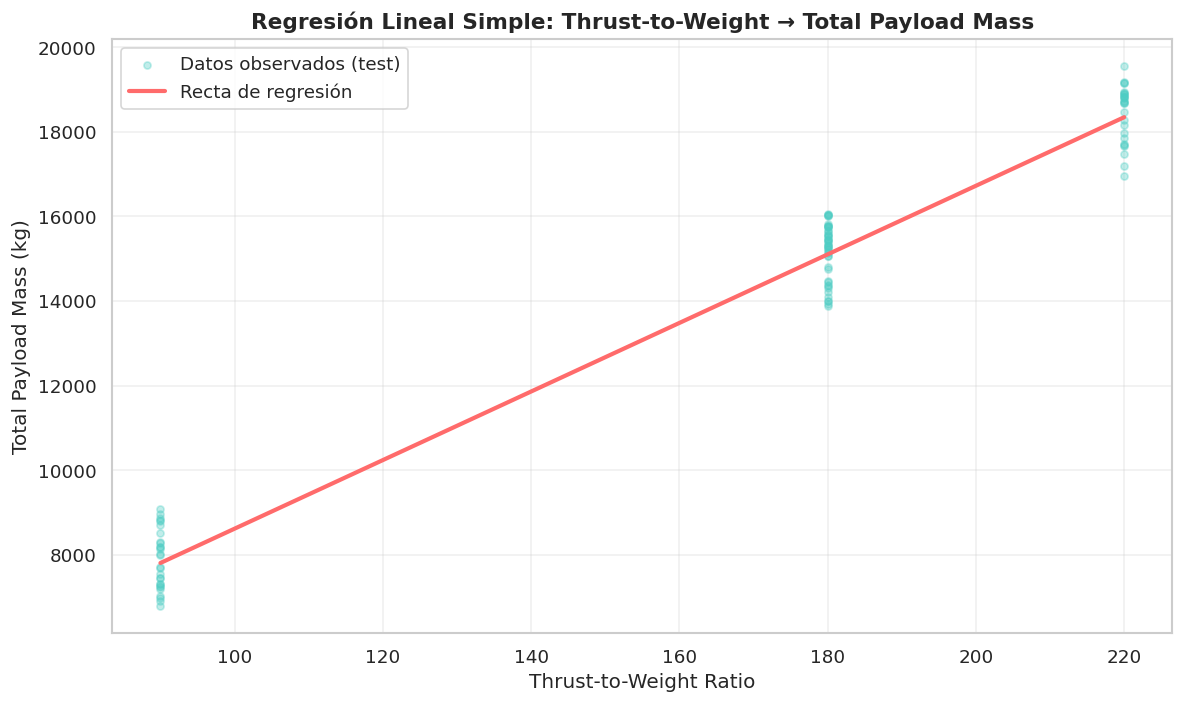

In [11]:
# ── CELDA 11: Recta de regresión ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
 
ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')
 
ax.set_xlabel('Thrust-to-Weight Ratio', fontsize=12)
ax.set_ylabel('Total Payload Mass (kg)', fontsize=12)
ax.set_title('Regresión Lineal Simple: Thrust-to-Weight → Total Payload Mass',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('../data/graficas/regresion_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()
 

In [12]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────
r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)
 
print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.9739  (97.39%)
  MSE  (error cuadrático med)  : 441318.5321
  RMSE (raíz del MSE)          : 664.3181
  MAE  (error absoluto medio)  : 577.7775


In [13]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────
X_ols = sm.add_constant(df['thrust_to_weight'])
modelo_ols_simple = sm.OLS(df['total_payload_mass'], X_ols).fit()
 
print(modelo_ols_simple.summary())
 

                            OLS Regression Results                            
Dep. Variable:     total_payload_mass   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                 2.204e+04
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:00:58   Log-Likelihood:                -3953.9
No. Observations:                 500   AIC:                             7912.
Df Residuals:                     498   BIC:                             7920.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              518.5490     93.773  

Text(0.5, 0.98, 'Supuesto de Normalidad — Regresión Lineal Simple')

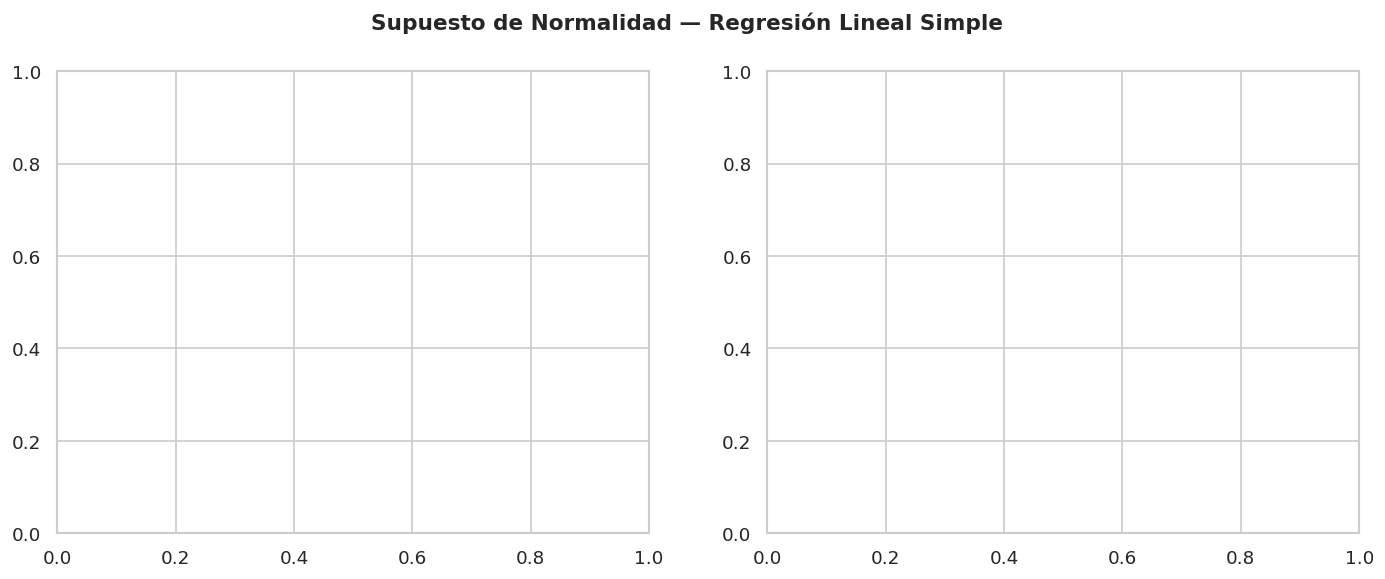

In [14]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────
y_pred_all = modelo_simple.predict(df[['thrust_to_weight']].values)
residuos   = df['total_payload_mass'].values - y_pred_all
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

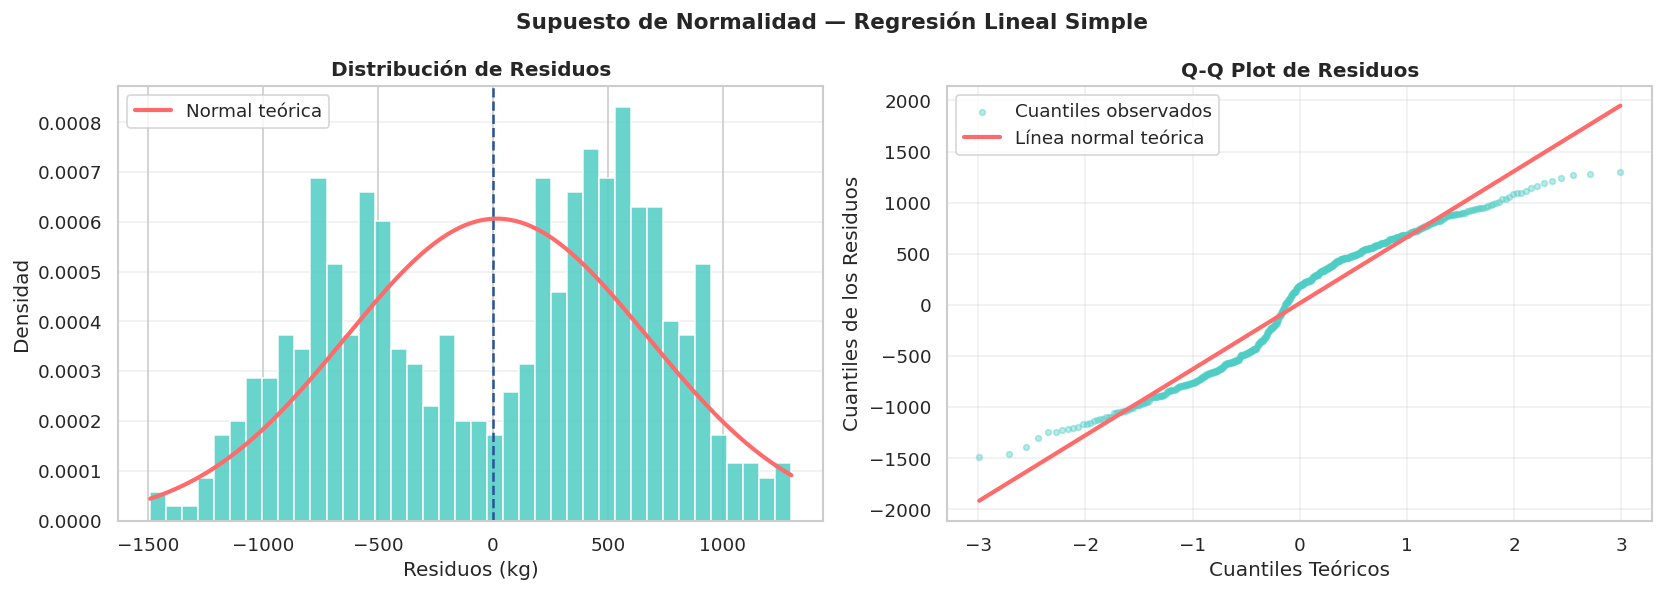


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9516
   p-value       : 0.000000
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n=500 y r=0.99 el test es muy sensible a desviaciones
         leves — evaluar normalidad visual con el Q-Q plot.


In [15]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────
y_pred_all = modelo_simple.predict(df[['thrust_to_weight']].values)
residuos   = df['total_payload_mass'].values - y_pred_all
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')
 
# Histograma con curva normal superpuesta
axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (kg)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
 
# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig('../data/graficas/normalidad_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
# ── Test Shapiro-Wilk (máximo 5000 muestras por limitación estadística)
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000,
                                                    replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)
 
print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")
if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con n=500 y r=0.99 el test es muy sensible a desviaciones")
    print("         leves — evaluar normalidad visual con el Q-Q plot.")
 

/home/elkin_contreras/repositorio/Grupo1_Contreras_Ortiz/04-jupyter-impl/venv/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


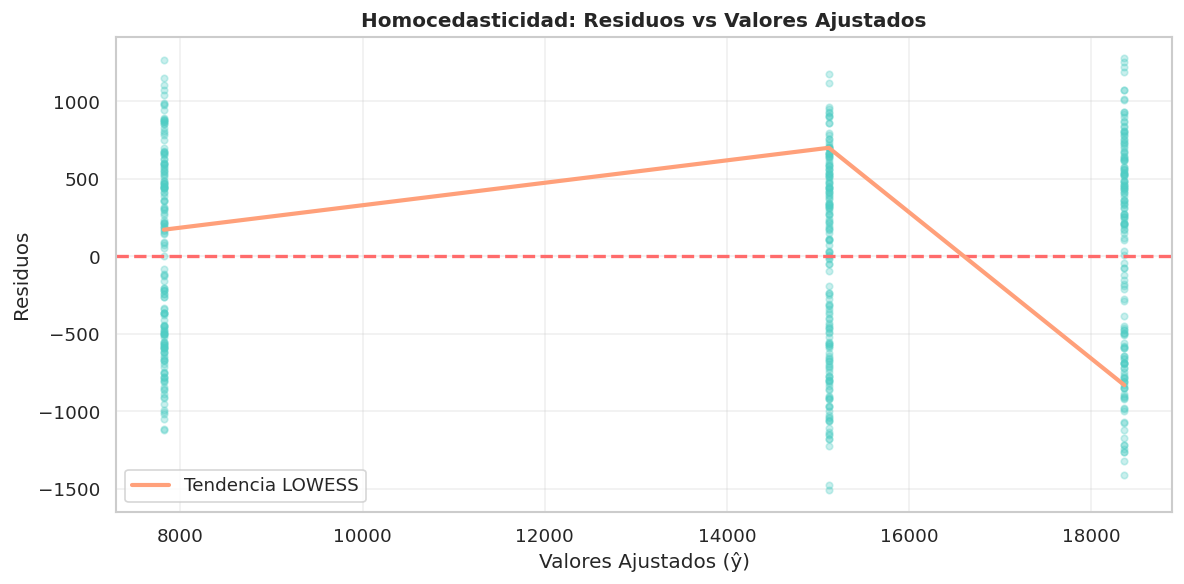


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 5.0836
   p-value        : 0.024154
   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)
   Nota: Con r=0.99 los residuos pueden variar por grupos de cohete.
         Evaluar el gráfico LOWESS para confirmar el patrón.


In [16]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues
 
plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/graficas/homoc_simple.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
# ── Test de Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(residuos_ols,
                                       modelo_ols_simple.model.exog)
 
print(f"\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")
if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")
    print("   Nota: Con r=0.99 los residuos pueden variar por grupos de cohete.")
    print("         Evaluar el gráfico LOWESS para confirmar el patrón.")